In [ ]:
#training xgboost
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier, XGBRegressor
from skopt.space import Real, Categorical, Integer
from skopt import BayesSearchCV
from sklearn.metrics import mean_squared_error, r2_score
#pip install xgboost
#pip install --upgrade category_encoders
#pip install scikit-optimize
from pathlib import Path


filepath = Path.home() / "Downloads"

#replace this with the name of the data file
df1 = pd.read_csv(filepath/'2023_feature_data_train.csv', delimiter=',')
df2 = pd.read_csv(filepath/'2025_feature_data_train.csv', delimiter=',')
#getting rid of features that are not very useful
#rename columns so they are undersetandable
combined = pd.concat([df1, df2], ignore_index=True) 
combined.head()
cat_cols = ['cloud_cover', 'season']
X = combined.drop(columns=['egse_percent_demand_0_1', 'egse_percent_demand_0_25',  'egse_percent_demand_0_5','egse_percent_demand_0_75', 'egse_percent_demand_1'])
Y = combined[['egse_percent_demand_0_1', 'egse_percent_demand_0_25', 'egse_percent_demand_0_5', 'egse_percent_demand_0_75', 'egse_percent_demand_1']]
X.head()

X[cat_cols] = X[cat_cols].astype(str).astype('category')



for col in X.select_dtypes(['object']):
    X[col] = X[col].astype('category')

#1st xgboost parameters
# model = XGBRegressor(objective= 'reg:squarederror',
#     max_depth= 3,
#     learning_rate= 0.1,
#     n_estimators= 100,
#     subsample= 0.8,
#     colsample_bytree= 0.8,
#     random_state= 42,
#     enable_categorical= True)

model = XGBRegressor(
    objective='reg:squarederror',

    #n_estimators=500,
    #learning_rate=0.03,

    #updated parameters after search
    n_estimators = 121,
    learning_rate = 0.051,

    #max_depth=4,
    max_depth = 5,

    min_child_weight=5,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=2,

    random_state=42,
    enable_categorical=True
)

model.fit(X, Y)


# Make predictions on the test set
y_pred = model.predict(X)

C:\Users\alecg\AppData\Local\Temp\ipykernel_21120\3802990539.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(['object']):


In [ ]:
#train xgboost with search for better parameters
import pandas as pd
from pathlib import Path

from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# --------------------
# LOAD TRAIN DATA
# --------------------
filepath = Path.home() / "Downloads"

df1 = pd.read_csv(filepath/'2023_feature_data_train.csv')
df2 = pd.read_csv(filepath/'2025_feature_data_train.csv')

combined = pd.concat([df1, df2], ignore_index=True)

cat_cols = ['cloud_cover', 'season']

X_train = combined.drop(columns=[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
])

y_train = combined[[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
]]

# --------------------
# HANDLE CATEGORICAL DATA
# --------------------
X_train[cat_cols] = X_train[cat_cols].astype(str).astype('category')

for col in X_train.select_dtypes(['object']):
    X_train[col] = X_train[col].astype('category')


# --------------------
# LOAD VALIDATION DATA
# --------------------
val_df1 = pd.read_csv(filepath/'2023_feature_data_val.csv')
val_df2 = pd.read_csv(filepath/'2025_feature_data_val.csv')

val_df = pd.concat([val_df1, val_df2], ignore_index=True)

X_val = val_df.drop(columns=[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
])

y_val = val_df[[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
]]

# --------------------
# HANDLE VALIDATION CATEGORICAL DATA
# --------------------
X_val[cat_cols] = X_val[cat_cols].astype(str).astype('category')

for col in X_val.select_dtypes(['object']):
    X_val[col] = X_val[col].astype('category')


# --------------------
# MODEL
# --------------------
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    enable_categorical=True
)


# --------------------
# HYPERPARAMETER SEARCH SPACE
# --------------------
param_space = {
    "n_estimators": Integer(100, 300),
    "max_depth": Integer(3, 5),
    "learning_rate": Real(0.03, 0.1, prior='log-uniform')
}


# --------------------
# BAYESIAN SEARCH
# --------------------
search = BayesSearchCV(
    estimator=xgb,
    search_spaces=param_space,

    n_iter=5,
    cv=2,

    scoring='neg_mean_absolute_error',

    random_state=42,
    n_jobs=-1,
    verbose=1
)


# --------------------
# TRAIN MODELS + FIND BEST PARAMETERS
# --------------------
search.fit(X_train, y_train)


# --------------------
# BEST MODEL
# --------------------
best_model = search.best_estimator_

print("Best params:")
print(search.best_params_)


# --------------------
# VALIDATION PREDICTIONS
# --------------------
y_pred = best_model.predict(X_val)


# --------------------
# METRICS
# --------------------
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_val, y_pred)


# --------------------
# PRINT RESULTS
# --------------------
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

#I ran this then went back to original xgboost code (first code block)
#and implemented the new parameters. 

C:\Users\alecg\AppData\Local\Temp\ipykernel_21120\1101562142.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(['object']):
C:\Users\alecg\AppData\Local\Temp\ipykernel_21120\1101562142.py:80: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migrati

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params:
OrderedDict({'learning_rate': 0.05125246061944595, 'max_depth': 5, 'n_estimators': 121})
MAE: 101.41279602050781
MSE: 30972.79296875
RMSE: 175.99088887993605
R2: 0.943397045135498


In [ ]:
#validation data check
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# =========================
# LOAD VALIDATION DATA
# =========================

val_df1 = pd.read_csv(filepath/'2023_feature_data_val.csv', delimiter=',')
val_df2 = pd.read_csv(filepath/'2025_feature_data_val.csv', delimiter=',')
#getting rid of features that are not very useful
#rename columns so they are undersetandable
val_df = pd.concat([val_df1, val_df2], ignore_index=True) 


# =========================
# SPLIT FEATURES/TARGETS
# =========================

X_val = val_df.drop(columns=[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
])

Y_val = val_df[[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
]]

# =========================
# HANDLE CATEGORICAL DATA
# =========================

X_val[cat_cols] = X_val[cat_cols].astype(str).astype('category')

for col in X_val.select_dtypes(['object']):
    X_val[col] = X_val[col].astype('category')

# =========================
# MAKE PREDICTIONS
# =========================

y_pred = model.predict(X_val)

# =========================
# CALCULATE METRICS
# =========================

mae = mean_absolute_error(Y_val, y_pred)
mse = mean_squared_error(Y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_val, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)    
print("R²:", r2)

C:\Users\alecg\AppData\Local\Temp\ipykernel_21120\334599568.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_val.select_dtypes(['object']):


MAE: 104.79730224609375
MSE: 33525.6015625
RMSE: 183.0999769593104
R²: 0.9392372965812683


In [ ]:
#test data check
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# =========================
# LOAD Test DATA
# =========================

val_df1 = pd.read_csv(filepath/'2023_feature_data_test.csv', delimiter=',')
val_df2 = pd.read_csv(filepath/'2025_feature_data_test.csv', delimiter=',')
#getting rid of features that are not very useful
#rename columns so they are undersetandable
val_df = pd.concat([val_df1, val_df2], ignore_index=True) 


# =========================
# SPLIT FEATURES/TARGETS
# =========================

X_val = val_df.drop(columns=[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
])

Y_val = val_df[[
    'egse_percent_demand_0_1',
    'egse_percent_demand_0_25',
    'egse_percent_demand_0_5',
    'egse_percent_demand_0_75',
    'egse_percent_demand_1'
]]

# =========================
# HANDLE CATEGORICAL DATA
# =========================

X_val[cat_cols] = X_val[cat_cols].astype(str).astype('category')

for col in X_val.select_dtypes(['object']):
    X_val[col] = X_val[col].astype('category')

# =========================
# MAKE PREDICTIONS
# =========================

y_pred = model.predict(X_val)

# =========================
# CALCULATE METRICS
# =========================

mae = mean_absolute_error(Y_val, y_pred)
mse = mean_squared_error(Y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_val, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)    
print("R²:", r2)

C:\Users\alecg\AppData\Local\Temp\ipykernel_21120\1965861264.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_val.select_dtypes(['object']):


MAE: 92.91869354248047
MSE: 25540.748046875
RMSE: 159.8147303813857
R²: 0.9551820755004883


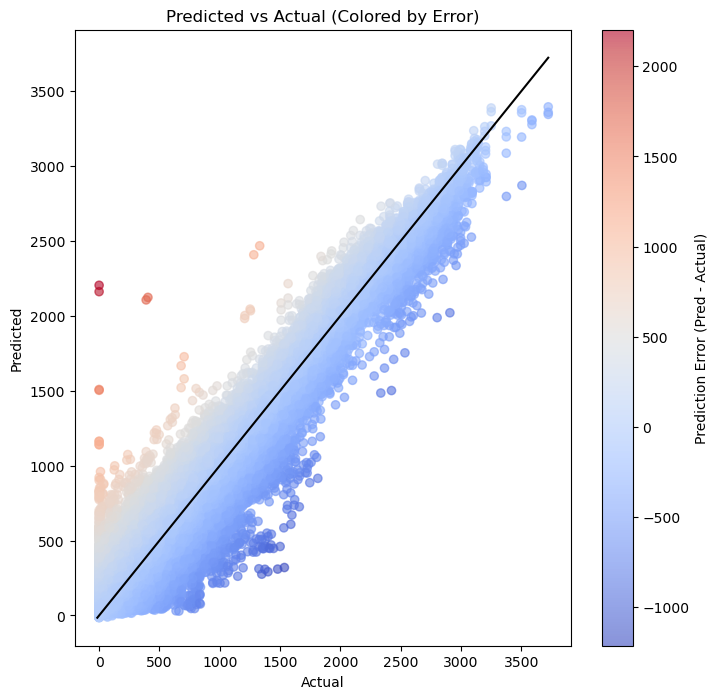

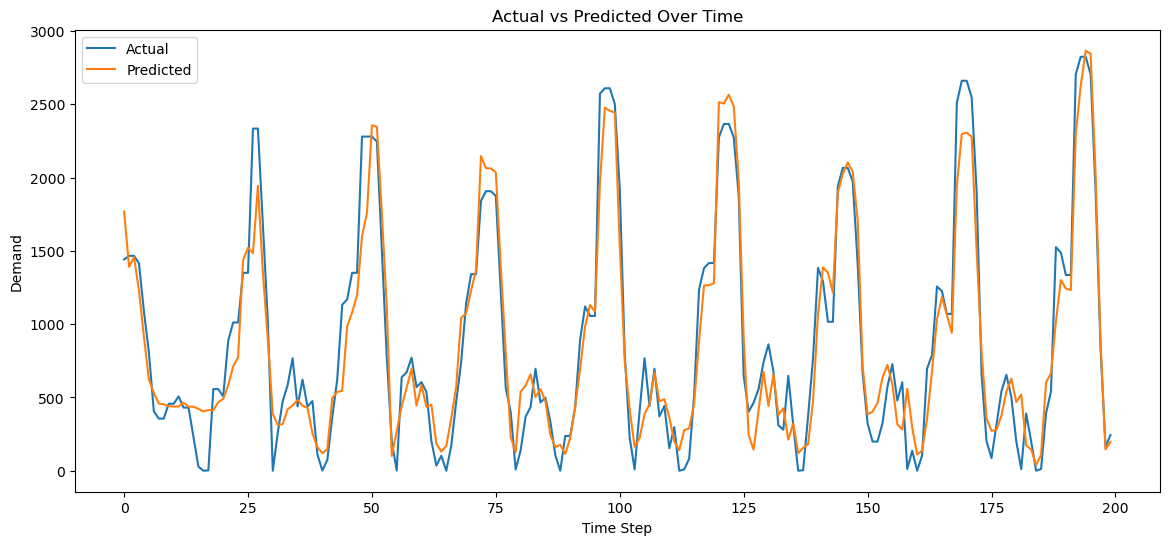

<Figure size 1000x800 with 0 Axes>

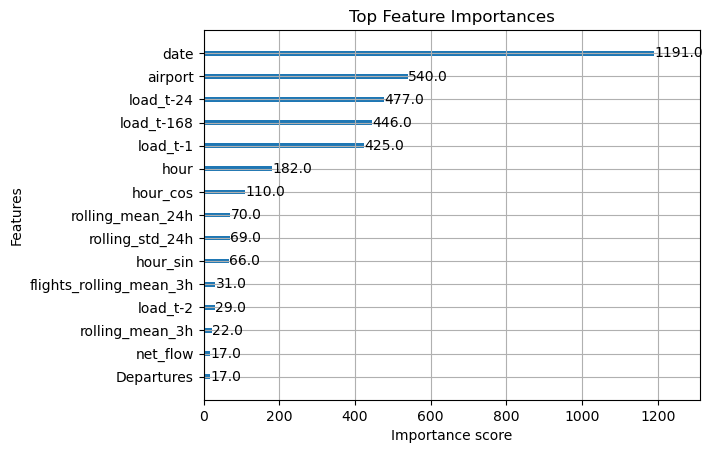

In [17]:
#visualization code 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import plot_importance


# =========================================================
# 1. PREDICTED VS ACTUAL SCATTER PLOT
# =========================================================

#1st scatterplot commented out
# choose ONE target column to visualize
# target_col = 'egse_percent_demand_0_5'
# target_idx = 2  # index in your multi-output array

# actual = Y_val[target_col].values
# predicted = y_pred[:, target_idx]

# print(actual.shape)
# print(predicted.shape)  # should match now

# plt.figure(figsize=(8, 8))
# plt.scatter(actual, predicted, alpha=0.5)

# min_val = min(actual.min(), predicted.min())
# max_val = max(actual.max(), predicted.max())

# plt.plot([min_val, max_val], [min_val, max_val])

# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("Predicted vs Actual")
# plt.show()


errors = predicted - actual

plt.figure(figsize=(8, 8))

sc = plt.scatter(
    actual,
    predicted,
    c=errors,
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(sc, label="Prediction Error (Pred - Actual)")

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())

plt.plot([min_val, max_val], [min_val, max_val], color='black')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Colored by Error)")
plt.show()


# =========================================================
# 2. ACTUAL VS PREDICTED TIME SERIES
# =========================================================

# show only first 200 points so graph is readable
num_points = 200

plt.figure(figsize=(14, 6))

plt.plot(actual[:num_points], label="Actual")
plt.plot(predicted[:num_points], label="Predicted")

plt.xlabel("Time Step")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Over Time")
plt.legend()
plt.show()



# =========================================================
# 3. FEATURE IMPORTANCE
# =========================================================

# train single-output model for plotting importance
# (xgboost importance plotting works better this way)

single_y = y_train['egse_percent_demand_0_5']

importance_model = best_model
#seperate model for visualization
importance_model.fit(X_train, single_y)

plt.figure(figsize=(10, 8))

plot_importance(
    importance_model,
    max_num_features=15
)

plt.title("Top Feature Importances")

plt.show()